Fruit types: ['pupunha', 'graviola', 'acai', 'guarana', 'cupuacu', 'tucuma']


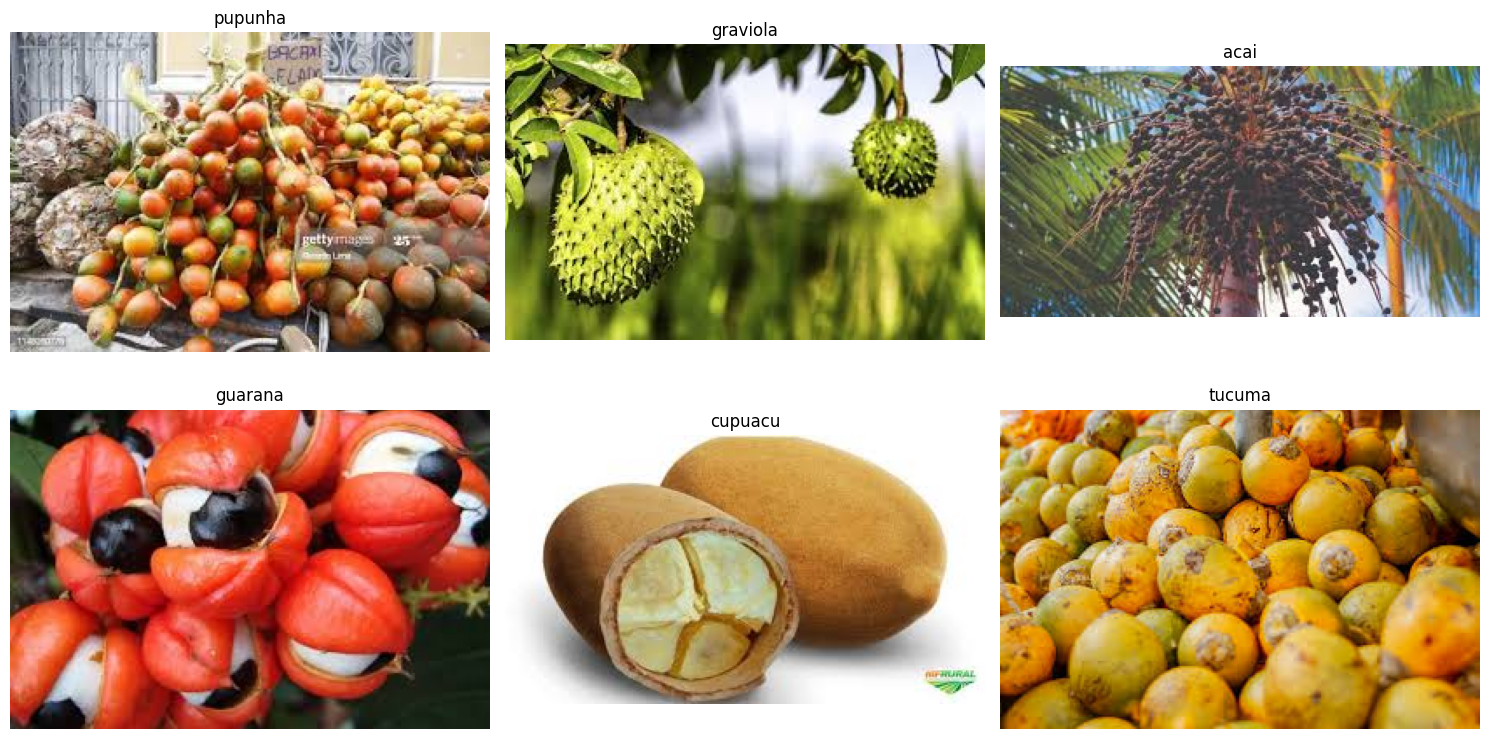

In [1]:
import os
import matplotlib.pyplot as plt
import random
from PIL import Image

# Path to your train folder
train_path = "/content/drive/MyDrive/AI/Data/FruitinAmazon/train"

# Get all class names (subfolder names)
classes = os.listdir(train_path)
print("Fruit types:", classes)

# Create a grid with 2 rows
fig, axes = plt.subplots(2, len(classes)//2 + len(classes)%2, figsize=(15, 8))
axes = axes.flatten()  # Make it easier to loop through

# For each fruit type, pick one random image
for i, fruit_class in enumerate(classes):
    class_path = os.path.join(train_path, fruit_class)
    # Get all images in this folder
    images = os.listdir(class_path)
    # Pick one random image
    random_image = random.choice(images)
    image_path = os.path.join(class_path, random_image)

    # Load and display the image
    img = Image.open(image_path)
    axes[i].imshow(img)
    axes[i].set_title(fruit_class)
    axes[i].axis('off')  # Hide axes

plt.tight_layout()
plt.show()

In [2]:
from PIL import Image
import os

train_path = "/content/drive/MyDrive/AI/Data/FruitinAmazon/train"
corrupted_images = []

# Walk through every folder and file
for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)
    if os.path.isdir(class_path):  # Make sure it's a folder
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            try:
                # Try to open the image
                img = Image.open(image_path)
                img.verify()  # Check if it's a valid image
            except (IOError, SyntaxError) as e:
                # If error occurs, image is corrupted
                print(f"Removed corrupted image: {image_path}")
                os.remove(image_path)  # Delete the bad file
                corrupted_images.append(image_path)

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


In [4]:
import tensorflow as tf

# Set these based on your images
img_height = 128   # Resize all images to this height
img_width = 128    # Resize all images to this width
batch_size = 32    # Process 32 images at a time
validation_split = 0.2  # Use 20% of training data for validation

# Normalization - scales pixel values from 0-255 to 0-1
# This helps the network learn faster and more stably
rescale = tf.keras.layers.Rescaling(1./255)

# Load TRAINING data (80% of your train folder)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/AI/Data/FruitinAmazon/train",  # Your train folder path
    labels='inferred',      # Use folder names as labels
    label_mode='int',       # Convert labels to numbers (apple=0, banana=1, etc.)
    image_size=(img_height, img_width),  # Resize all images
    batch_size=batch_size,  # 32 images per batch
    shuffle=True,           # Randomize order (important for learning!)
    validation_split=validation_split,  # Reserve 20% for validation
    subset='training',      # This is the training portion
    seed=123               # Makes results reproducible
)

# Store class names before mapping
class_names = train_ds.class_names

# Normalize the training data
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Load VALIDATION data (the other 20% of train folder)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/AI/Data/FruitinAmazon/train",
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,          # Don't shuffle validation data
    validation_split=validation_split,
    subset='validation',    # This is the validation portion
    seed=123
)

# Normalize validation data
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Load TEST data (use your separate test folder)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/AI/Data/FruitinAmazon/test",  # Your test folder path
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Find number of classes (how many fruit types)
num_classes = len(class_names)
print(f"Number of fruit types: {num_classes}")
print(f"Fruit types: {class_names}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Number of fruit types: 6
Fruit types: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [5]:
from tensorflow.keras import layers, models

model = models.Sequential([  # Sequential means layers go in order

    # ----- CONVOLUTIONAL BLOCK 1 -----
    # Conv Layer 1: 32 filters, 3x3 size, same padding, stride 1
    layers.Conv2D(filters=32, kernel_size=(3,3),
                  padding='same', strides=1,
                  activation='relu',
                  input_shape=(img_height, img_width, 3)),
    # Pooling Layer 1: 2x2 pool, stride 2
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # ----- CONVOLUTIONAL BLOCK 2 -----
    # Conv Layer 2: 32 filters, 3x3 size, same padding, stride 1
    layers.Conv2D(filters=32, kernel_size=(3,3),
                  padding='same', strides=1,
                  activation='relu'),
    # Pooling Layer 2: 2x2 pool, stride 2
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # ----- FULLY CONNECTED SECTION -----
    layers.Flatten(),  # Convert 2D features to 1D

    # Hidden Layer 1: 64 neurons
    layers.Dense(64, activation='relu'),

    # Hidden Layer 2: 128 neurons
    layers.Dense(128, activation='relu'),

    # Output Layer: num_classes neurons (one per fruit type)
    # Softmax converts outputs to probabilities that sum to 1
    layers.Dense(num_classes, activation='softmax')
])

# Show the model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# STEP 1: COMPILE THE MODEL
# This configures how the model learns
model.compile(
    optimizer='adam',  # Adaptive learning rate optimizer (works well for most cases)
    loss='sparse_categorical_crossentropy',  # For integer labels (0,1,2,etc.)
    metrics=['accuracy']  # Track accuracy during training
)

# STEP 2: SET UP CALLBACKS
# Callbacks are functions that run during training
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model (lowest validation loss)
checkpoint = ModelCheckpoint(
    'best_fruit_model.h5',  # Filename to save
    monitor='val_loss',      # Watch validation loss
    save_best_only=True,     # Only save if it's better than previous best
    verbose=1                # Print messages when saving
)

# Stop training if validation loss doesn't improve for 10 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,     # Wait 10 epochs before stopping
    restore_best_weights=True,  # Go back to best model
    verbose=1
)

# STEP 3: TRAIN THE MODEL
history = model.fit(
    train_ds,                    # Training data
    validation_data=val_ds,      # Validation data
    epochs=250,                  # Maximum 250 passes through the data
    batch_size=16,               # Process 16 images at a time
    callbacks=[checkpoint, early_stop],  # Our callbacks
    verbose=1                    # Show progress bars
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.2043 - loss: 1.8193
Epoch 1: val_loss improved from None to 1.19146, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 559ms/step - accuracy: 0.2222 - loss: 1.8368 - val_accuracy: 0.8333 - val_loss: 1.1915
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.1719 - loss: 1.7196
Epoch 2: val_loss did not improve from 1.19146
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 340ms/step - accuracy: 0.2500 - loss: 1.7015 - val_accuracy: 0.6111 - val_loss: 1.3873
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.4635 - loss: 1.4782
Epoch 3: val_loss did not improve from 1.19146
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 351ms/step - accuracy: 0.5000 - loss: 1.4249 - val_accuracy: 0.2222 - val_loss: 1.7717
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.4138 - loss: 1.3427
Epoch 4: val_loss improved from 1.19146 to 1.10524, saving model to best_fruit_model.h5



Epoch 4: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 389ms/step - accuracy: 0.4444 - loss: 1.2876 - val_accuracy: 0.5556 - val_loss: 1.1052
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.5556 - loss: 1.0740
Epoch 5: val_loss improved from 1.10524 to 1.05101, saving model to best_fruit_model.h5



Epoch 5: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 369ms/step - accuracy: 0.5417 - loss: 1.0958 - val_accuracy: 0.6111 - val_loss: 1.0510
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.4757 - loss: 1.0781
Epoch 6: val_loss improved from 1.05101 to 0.85795, saving model to best_fruit_model.h5



Epoch 6: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 574ms/step - accuracy: 0.4583 - loss: 1.1532 - val_accuracy: 0.7778 - val_loss: 0.8579
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.7627 - loss: 0.7414
Epoch 7: val_loss did not improve from 0.85795
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 377ms/step - accuracy: 0.6944 - loss: 0.7909 - val_accuracy: 0.4444 - val_loss: 1.1668
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.6626 - loss: 0.8303
Epoch 8: val_loss did not improve from 0.85795
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 353ms/step - accuracy: 0.7222 - loss: 0.7613 - val_accuracy: 0.5556 - val_loss: 1.0961
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.8455 - loss: 0.5737
Epoch 9: val_loss improved from 0.85795 to 0.42296, saving model to best_fruit_model.h5


...


Epoch 10: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 393ms/step - accuracy: 0.8750 - loss: 0.4766 - val_accuracy: 0.8889 - val_loss: 0.4161
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9450 - loss: 0.3360
Epoch 11: val_loss did not improve from 0.41608
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 335ms/step - accuracy: 0.9444 - loss: 0.3244 - val_accuracy: 0.6111 - val_loss: 0.9524
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.9404 - loss: 0.2854
Epoch 12: val_loss did not improve from 0.41608
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 358ms/step - accuracy: 0.9306 - loss: 0.2756 - val_accuracy: 0.8889 - val_loss: 0.4784
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.9699 - loss: 0.1792
Epoch 13: val_loss did not improve from 0.41608
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 331ms/step - accuracy: 0.9722 - loss: 0.1738 - val_accuracy: 0.7222 - val_loss: 0.5105
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9497 - loss: 0.1


Epoch 14: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 587ms/step - accuracy: 0.9583 - loss: 0.1640 - val_accuracy: 0.8889 - val_loss: 0.3376
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 1.0000 - loss: 0.0733
Epoch 15: val_loss did not improve from 0.33764
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 437ms/step - accuracy: 1.0000 - loss: 0.0716 - val_accuracy: 0.8333 - val_loss: 0.4082
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 1.0000 - loss: 0.0667
Epoch 16: val_loss improved from 0.33764 to 0.32244, saving model to best_fruit_model.h5



Epoch 16: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 413ms/step - accuracy: 1.0000 - loss: 0.0610 - val_accuracy: 0.8333 - val_loss: 0.3224
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 1.0000 - loss: 0.0302
Epoch 17: val_loss improved from 0.32244 to 0.25567, saving model to best_fruit_model.h5



Epoch 17: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 376ms/step - accuracy: 1.0000 - loss: 0.0320 - val_accuracy: 0.9444 - val_loss: 0.2557
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 1.0000 - loss: 0.0191
Epoch 18: val_loss improved from 0.25567 to 0.22444, saving model to best_fruit_model.h5



Epoch 18: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 384ms/step - accuracy: 1.0000 - loss: 0.0197 - val_accuracy: 0.8889 - val_loss: 0.2244
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 1.0000 - loss: 0.0154
Epoch 19: val_loss did not improve from 0.22444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 320ms/step - accuracy: 1.0000 - loss: 0.0164 - val_accuracy: 0.8889 - val_loss: 0.2432
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 1.0000 - loss: 0.0136
Epoch 20: val_loss did not improve from 0.22444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 324ms/step - accuracy: 1.0000 - loss: 0.0153 - val_accuracy: 0.8889 - val_loss: 0.2319
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 1.0000 - loss: 0.0058
Epoch 21: val_loss did not improve from 0.22444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 323ms/step - accuracy: 1.0000 - loss: 0.0069 - val_accuracy: 0.9444 - val_loss: 0.2597
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 1.0000 - loss: 0.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.6333 - loss: 1.1940
Test Loss: 1.1940
Test Accuracy: 0.6333


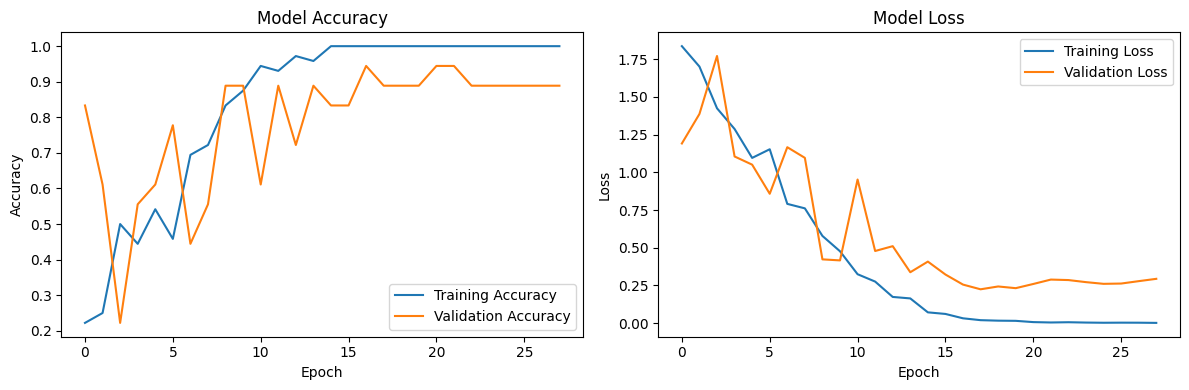

In [7]:
# Evaluate on test data (completely unseen images!)
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Plot training history to see if model learned well
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
# SAVE the trained model
model.save('fruit_classifier_model.h5')
print("Model saved as 'fruit_classifier_model.h5'")

# LOAD the saved model later (in a new session)
from tensorflow.keras.models import load_model
loaded_model = load_model('fruit_classifier_model.h5')

# Verify it still works
test_loss, test_accuracy = loaded_model.evaluate(test_ds)
print(f"Loaded model test accuracy: {test_accuracy:.4f}")

Model saved as 'fruit_classifier_model.h5'
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step - accuracy: 0.6333 - loss: 1.1940
Loaded model test accuracy: 0.6333


In [10]:
import numpy as np
from sklearn.metrics import classification_report

# Get all test images and true labels
all_predictions = []
all_true_labels = []

# Loop through test dataset batches
for images, labels in test_ds:
    # Make predictions on this batch
    predictions = model.predict(images, verbose=0)
    # Get the predicted class (highest probability)
    predicted_classes = np.argmax(predictions, axis=1)

    all_predictions.extend(predicted_classes)
    all_true_labels.extend(labels.numpy())

# Generate classification report
# This shows precision, recall, f1-score for each fruit type
report = classification_report(
    all_true_labels,
    all_predictions,
    target_names=class_names  # Use actual fruit names
)
print("CLASSIFICATION REPORT:")
print(report)

# Let's also see some example predictions
print("\n--- SAMPLE PREDICTIONS ---")
sample_images, sample_labels = next(iter(test_ds.take(1)))
sample_predictions = model.predict(sample_images)

for i in range(min(5, len(sample_images))):
    predicted = np.argmax(sample_predictions[i])
    actual = sample_labels[i]
    confidence = sample_predictions[i][predicted]

    print(f"Image {i+1}:")
    print(f"  Predicted: {class_names[predicted]} ({confidence:.2%})")
    print(f"  Actual: {class_names[actual]}")
    print(f"  Correct: {predicted == actual}")
    print()

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        acai       0.50      0.80      0.62         5
     cupuacu       0.50      0.60      0.55         5
    graviola       0.67      0.80      0.73         5
     guarana       0.60      0.60      0.60         5
     pupunha       1.00      0.60      0.75         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.63        30
   macro avg       0.71      0.63      0.63        30
weighted avg       0.71      0.63      0.63        30


--- SAMPLE PREDICTIONS ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
Image 1:
  Predicted: acai (98.04%)
  Actual: acai
  Correct: True

Image 2:
  Predicted: cupuacu (50.24%)
  Actual: acai
  Correct: False

Image 3:
  Predicted: acai (99.99%)
  Actual: acai
  Correct: True

Image 4:
  Predicted: acai (100.00%)
  Actual: acai
  Correct: True

Image 5:
  Predicted: acai (99.97%)
  Actual: acai
  Correct: True

